# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [5]:
from cases.open_space.ngsolve_geometries import AnularDomain
from trefftz.dg.materials import Dielectric
R = 1.
r = 0.2


lc = 0.05
Lc = 2.
eps_r = 16.

material = Dielectric(relative_permittivity=eps_r)


mesh = AnularDomain(R=R, r=r, scatterer_material = material, verbosity=0, Lc=Lc, lc=lc)


In [6]:
from trefftz.dg.parameters import Elementwise
import numpy as np 

Regions = mesh.regions

refractive_index = Elementwise(mesh, {Regions.BACKGROUND: 1.,
                                      Regions.OMEGA: np.sqrt(material.eps_r)})


In [7]:
mesh.n_triangles

292

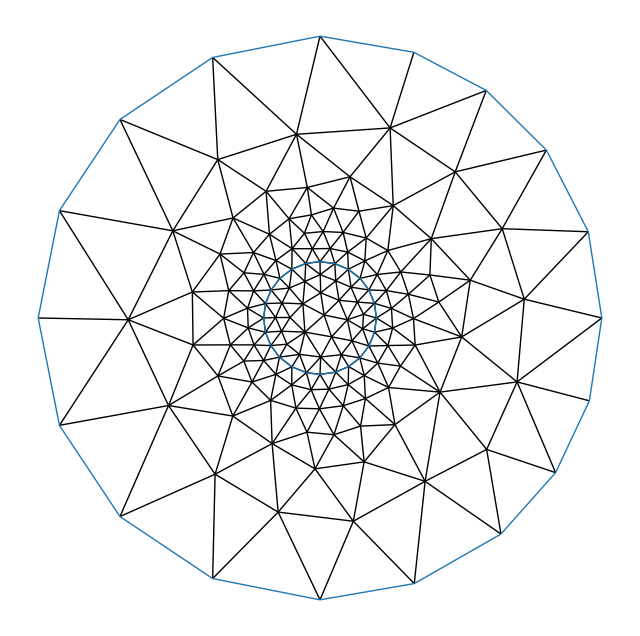

In [8]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

Text(0.5, 1.0, '$n=\\sqrt{\\varepsilon_\\mathrm{r}}$')

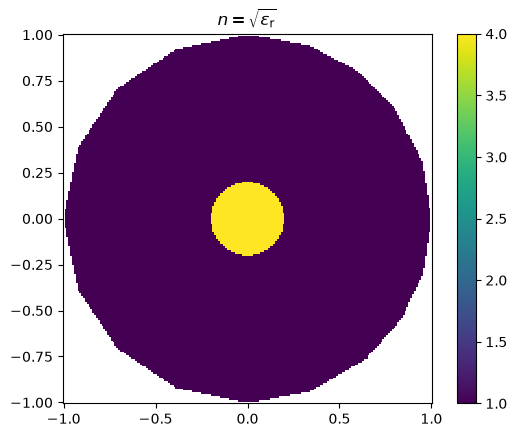

In [9]:
import matplotlib.pyplot as plt
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

Z = refractive_index(X, Y)

plt.pcolormesh(X, Y, Z)
plt.axis('square')
plt.colorbar()
plt.title('$n=\\sqrt{\\varepsilon_\\mathrm{r}}$')

In [10]:
Boundaries = mesh.boundaries
list(Boundaries)

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [11]:
mesh.curve_boundaries([Boundaries.SIGMA, Boundaries.D_OMEGA], radius=[R, r])


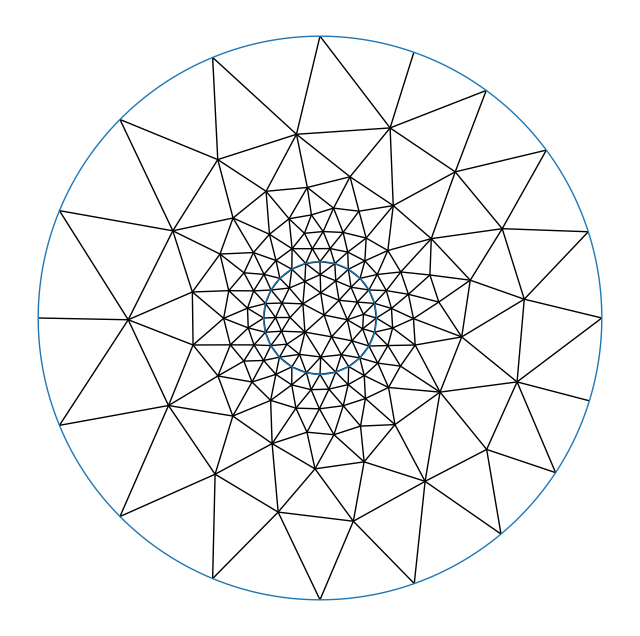

In [12]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [13]:
mesh.curved_boundaries

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [14]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [15]:
import numpy as np
from trefftz.dg.exact import PlaneWave
theta_inc = np.pi
d_inc = np.array([np.cos(theta_inc), np.sin(theta_inc)])
data = PlaneWave(d=d_inc, A=1.)
boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=data), Boundaries.D_OMEGA: DirichletBC(data=None)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [16]:
from trefftz.dg.block_fluxes import UltraWeakFlux

as well as specific ones (for a circular NtD map):

In [17]:
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [18]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 15
a = 0.5
b = 0.5
d2 = 0.5
numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=data)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = data)})

We should also choose a local basis

In [19]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
Ntheta = 12
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, refractive_index=refractive_index, k=k, N_theta=Ntheta)

and an assembler:

In [20]:
basis.N_DOF

3504

In [21]:
from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [22]:
assembler._regions_RHS_term

[<Boundaries.SIGMA: 'Sigma'>]

In [23]:
assembler._regions_local_kernel

[<Boundaries.SIGMA: 'Sigma'>]

so we can set the problem:

In [24]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [25]:
P.assemble_LHS()

assembling local operators
region: Sigma


Interior: 100%|██████████| 429/429 [00:00<00:00, 1400.17edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 18/18 [01:52<00:00,  6.25s/edge]


<COOrdinate sparse array of dtype 'complex128'
	with 296352 stored elements and shape (3504, 3504)>

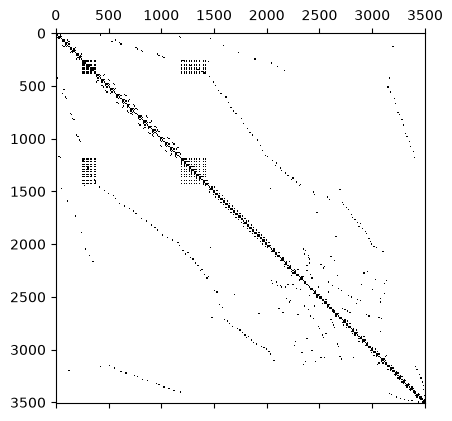

In [26]:
import matplotlib.pyplot as plt 
plt.spy(P.A.toarray())

In [35]:
P.assemble_RHS()

array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j], shape=(3504,))

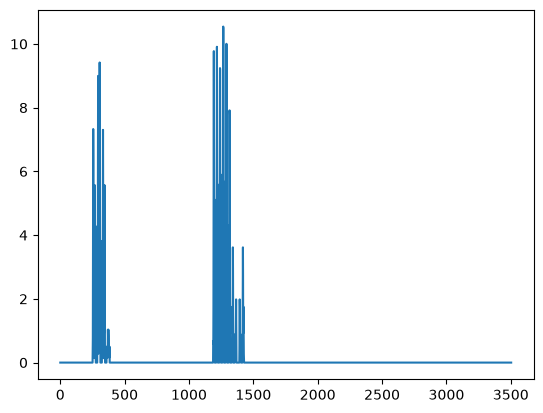

In [36]:
import numpy as np 
plt.plot(np.abs(P.b))

In [37]:
P.solve()

In [38]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[-2.13287446e+03-1.90407182e+02j,  1.16907069e+03+1.78736613e+03j,
         2.17236933e+02-2.09111584e+03j, ...,
        -4.26117323e+01-1.86996998e+03j, -3.36980245e+02+1.95291364e+03j,
         1.47370161e+03-1.47861175e+03j],
       [ 1.93948090e-01-1.79633226e-01j,  2.12156300e-01-3.89995992e-01j,
        -4.91936849e-02-3.47899048e-01j, ...,
        -1.88682166e-01-3.59059811e-01j,  7.37777663e-02+3.46393440e-01j,
         3.88101608e-01+1.18352511e-01j],
       [-1.51395968e+03-2.63221200e+02j,  7.81186663e+02+1.41459292e+03j,
         2.15346052e+02-1.67339167e+03j, ...,
        -1.72725187e+02-1.55824055e+03j, -2.41225271e+02+1.45995359e+03j,
         1.09590192e+03-9.88332521e+02j],
       ...,
       [-2.96297342e-01+4.22463425e-02j, -4.92422967e-02+3.22474769e-02j,
         6.55257216e-02-2.49658950e-02j, ...,
        -7.52914407e-02-6.07057006e-02j,  7.44048245e-02-8.17482454e-03j,
        -5.54525042e-02+2.05242615e-02j],
       [-3.22859540e-01+1.38982779e-02j, -2.

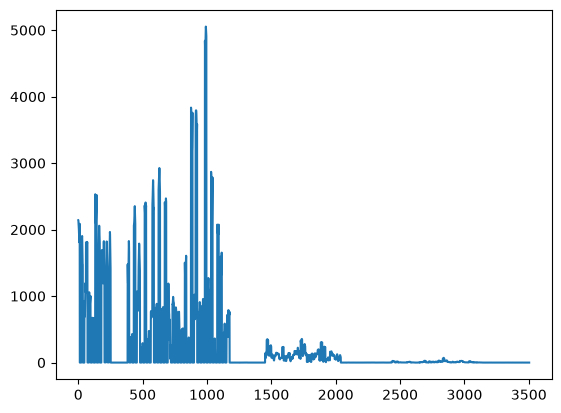

In [39]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

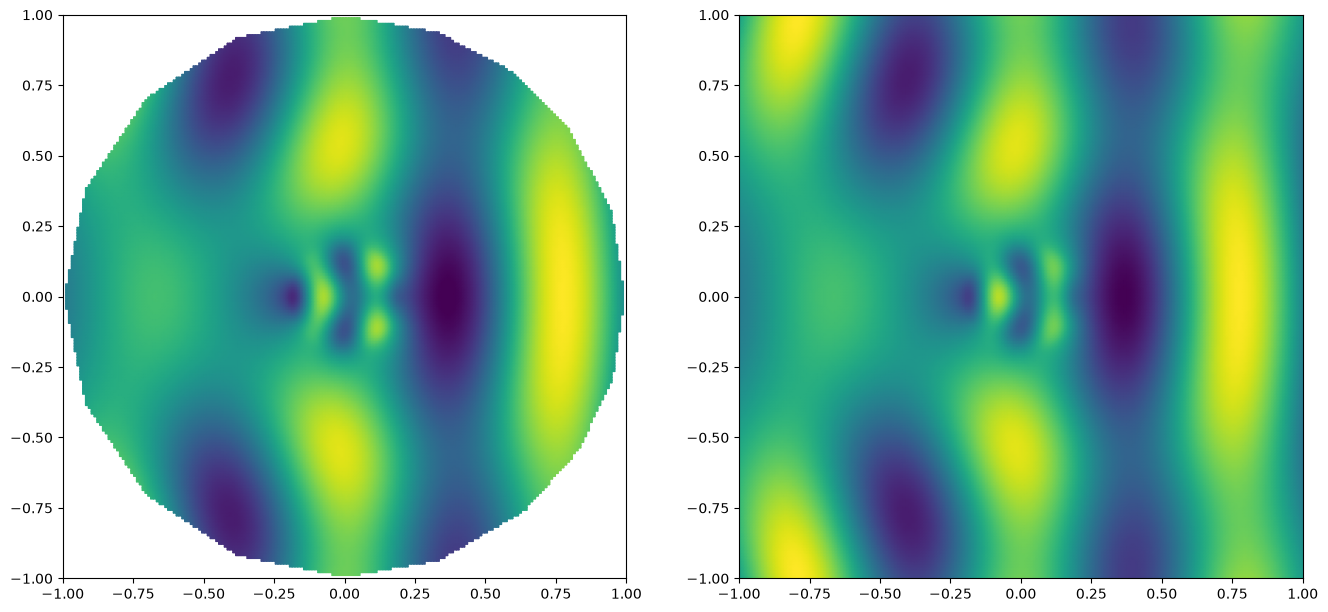

In [40]:
import matplotlib.pyplot as plt
from cases.open_space.exact import nf_diel_cylinder_plane_wave
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

U_h = P.u_h(X, Y)

U_s = nf_diel_cylinder_plane_wave(X, Y, k, theta_inc=np.pi, eps_r=eps_r, c=np.array([0., 0.]), R=r)
U_inc = np.exp(-1j*k*X)

RHO = np.sqrt(X**2 + Y**2)

U = np.where(RHO<r, U_s, U_s+U_inc)

fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmax = np.max(np.real(U))
vmin = np.min(np.real(U))

ax[0].pcolormesh(X, Y, np.real(U_h), vmin=vmin, vmax=vmax, shading="gouraud")
ax[0].axis('square')
ax[1].pcolormesh(X, Y, np.real(U), vmin=vmin, vmax=vmax, shading="gouraud")
ax[1].axis('square')


(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

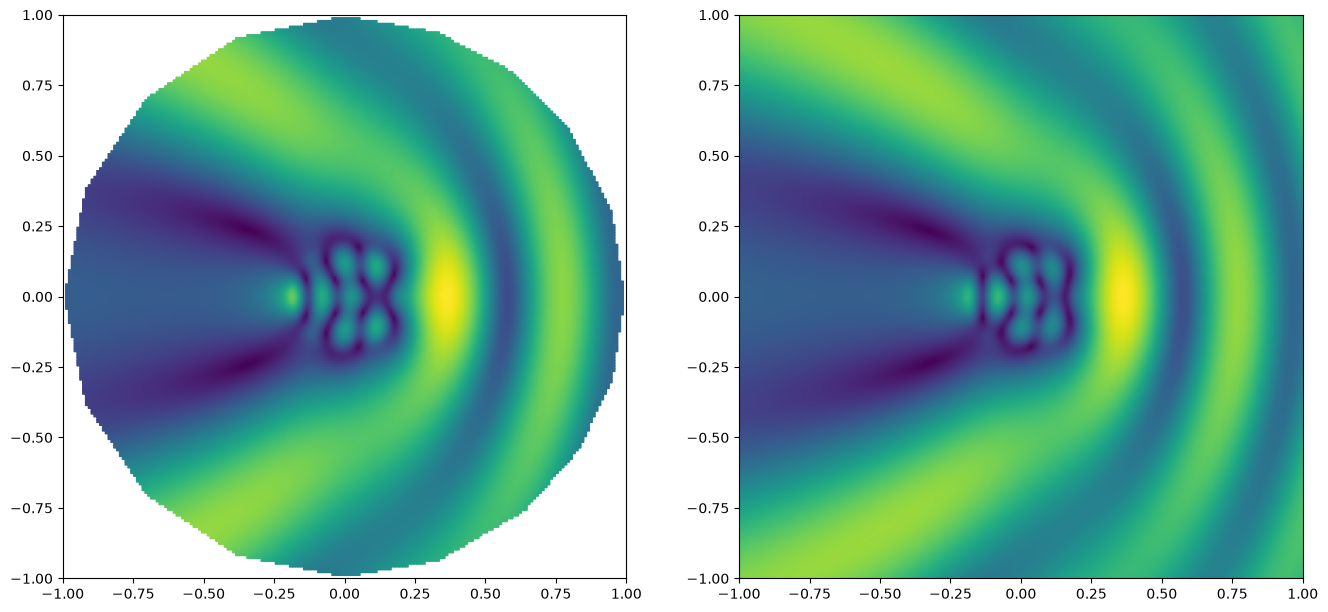

In [41]:
fig, ax = plt.subplots(ncols=2, figsize=(16,8))

ax[0].pcolormesh(X, Y, np.abs(U_h), shading="gouraud")
ax[0].axis('square')
ax[1].pcolormesh(X, Y, np.abs(U), shading="gouraud")
ax[1].axis('square')


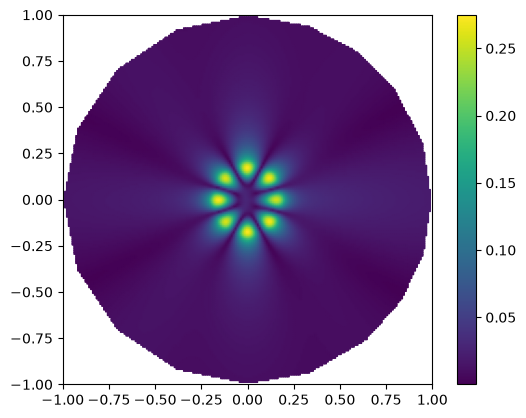

In [42]:
plt.pcolormesh(X, Y, np.abs(U_h - U), shading="gouraud")
plt.axis("square")
plt.colorbar()